# Data Science Workflow: Housing Recommendation
This notebook covers the complete data science workflow for building a Logistic Regression model to recommend housing models to prospective buyers. The workflow includes:
1. Data Cleaning and Preparation
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training
5. Model Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For training, scaling, and evaluating data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

## 1. Data Cleaning and Preparation
We begin by loading the dataset, checking for missing values, and formatting our columns appropriately.

In [2]:
# Import the dataset
buyer_lead_df = pd.read_csv("dataset.csv")

# See the first 5 rows
buyer_lead_df.head()

,Timestamp,Date,Client ID,Age,Income of Principal Buyer,Marital Status,No. of Family Members,Preferred Location,SOURCE OF LEAD,Source of Income,Employer,Preferred Pay Term,Age of Spouse,Income of Spouse,Recommended Model
0,01/05/2024 19:22:08,01/05/2024,Client 1,29,"PHP 125,500",Married,7,BATULAO,Facebook Ads,Locally Employed,bdo unibank,20-80 Pagibig Financing,30,"PHP 83,000",CALISTA END
1,01/06/2024 11:56:09,01/06/2024,Client 2,27,"PHP 61,000",Married,2,MAGALANG EAST,Facebook Ads,Self Employed/ Business Owner,independent contractor,20-80 Pagibig Financing,25,"PHP 42,500",CALISTA END
2,01/11/2024 20:54:34,01/11/2024,Client 3,42,"PHP 247,000",Single,N/a,GAPAN,Broker/Agent,OFW Land base,Aramco,20-80 Pagibig Financing,N/a,N/a,CALISTA END
3,01/15/2024 14:35:29,01/15/2024,Client 4,47,"PHP 32,500",Single,NaN,LIPA,Facebook Ads,OFW Land base,pricewaterhousecoopers uae,20-80 Pagibig Financing,NaN,NaN,CALISTA MID
4,01/17/2024 17:33:44,01/17/2024,Client 5,27,"PHP 243,000",Married,2,TAYABAS,Facebook Ads,OFW Land base,Hyundai engineering,20-80 Pagibig Financing,28,"PHP 224,500",CALISTA END


In [3]:
# Check basic information about the dataset
print("Total number of rows and columns:", buyer_lead_df.shape)
print("Missing values:")
print(buyer_lead_df.isnull().sum())
print("Information: ")
print(buyer_lead_df.info())

Total number of rows and columns: (756, 15)
Missing values:
Timestamp                      0
Date                           0
Client ID                      0
Age                            0
Income of Principal Buyer      0
Marital Status                 0
No. of Family Members        198
Preferred Location             0
SOURCE OF LEAD                 0
Source of Income               0
Employer                       0
Preferred Pay Term             0
Age of Spouse                207
Income of Spouse             207
Recommended Model              0
dtype: int64
Information: 
<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  756 non-null    str  
 1   Date                       756 non-null    str  
 2   Client ID                  756 non-null    str  
 3   Age                        756 non-null    int64


In [4]:
# Convert income to numeric for analysis
buyer_lead_df['Income_Numeric'] = (
    buyer_lead_df['Income of Principal Buyer']
    .astype(str)
    .str.replace('PHP', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

# Convert No. of Family Members to numeric, replacing N/a with 0
buyer_lead_df['No. of Family Members'] = pd.to_numeric(buyer_lead_df['No. of Family Members'], errors='coerce').fillna(0)

# Convert Spouse Age and Income. Replace N/a or missing with 0 since there is no spouse
buyer_lead_df['Age of Spouse'] = pd.to_numeric(buyer_lead_df['Age of Spouse'], errors='coerce').fillna(0)
buyer_lead_df['Income_of_Spouse_Numeric'] = (
    buyer_lead_df['Income of Spouse']
    .astype(str)
    .str.replace('PHP', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
).fillna(0)

# Engineered features to boost model performance
buyer_lead_df['Has_Spouse'] = (buyer_lead_df['Age of Spouse'] > 0).astype(int)
buyer_lead_df['Total_Household_Income'] = buyer_lead_df['Income_Numeric'] + buyer_lead_df['Income_of_Spouse_Numeric']
buyer_lead_df['Income_Per_Member'] = buyer_lead_df['Total_Household_Income'] / buyer_lead_df['No. of Family Members'].replace(0, 1)
buyer_lead_df['Age_Spouse_Diff'] = (buyer_lead_df['Age'] - buyer_lead_df['Age of Spouse']).abs().fillna(0)

print("Data cleaning and feature engineering complete.")
print(f"New columns added: Has_Spouse, Total_Household_Income, Income_Per_Member, Age_Spouse_Diff")

Data cleaning and feature engineering complete.
New columns added: Has_Spouse, Total_Household_Income, Income_Per_Member, Age_Spouse_Diff


## 2. Exploratory Analysis
We explore the demographic details of the buyers to understand patterns that could influence their choice of housing models.

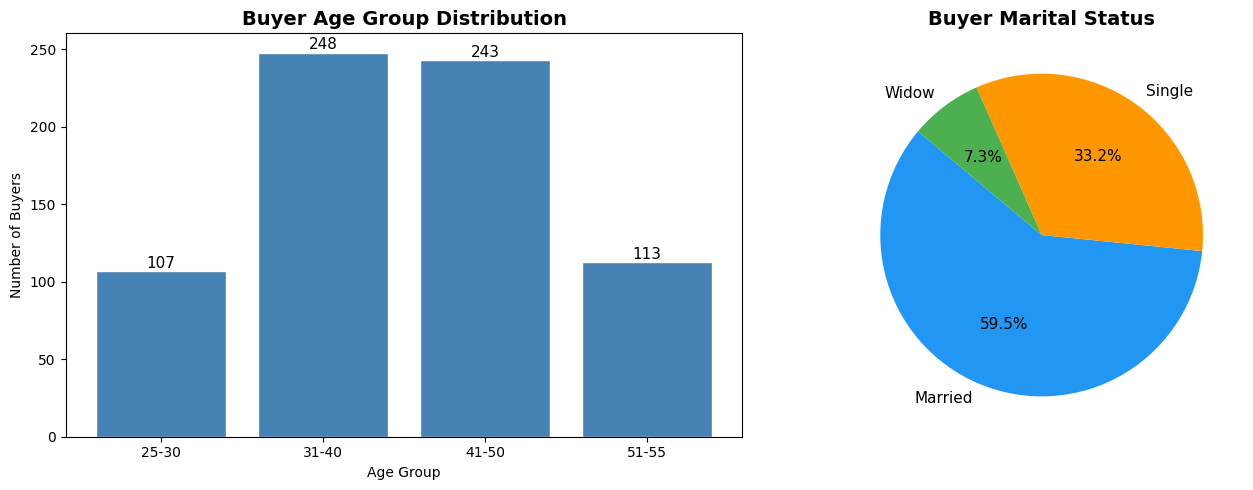

In [5]:
# Create age groups for EDA
bins = [24, 30, 40, 50, 56]
labels = ['25-30', '31-40', '41-50', '51-55']
buyer_lead_df['Age Group'] = pd.cut(buyer_lead_df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Group Distribution
age_counts = buyer_lead_df['Age Group'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Buyer Age Group Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Buyers')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Marital Status
marital_counts = buyer_lead_df['Marital Status'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50']
axes[1].pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Buyer Marital Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

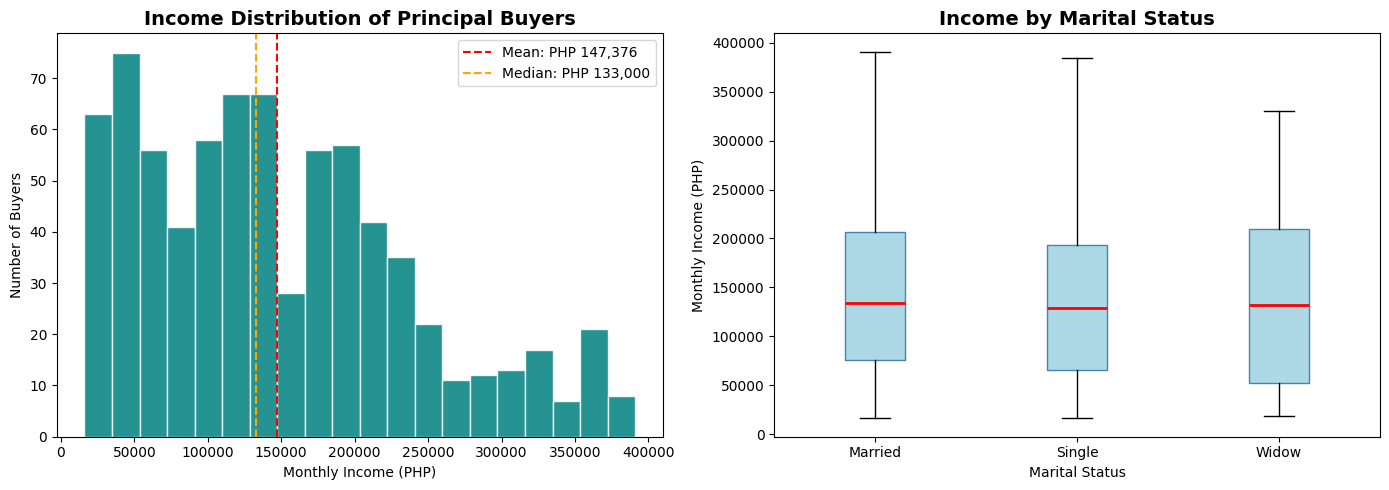

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income Histogram
axes[0].hist(buyer_lead_df['Income_Numeric'].dropna(), bins=20, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(buyer_lead_df['Income_Numeric'].mean(), color='red', linestyle='--', label=f"Mean: PHP {buyer_lead_df['Income_Numeric'].mean():,.0f}")
axes[0].axvline(buyer_lead_df['Income_Numeric'].median(), color='orange', linestyle='--', label=f"Median: PHP {buyer_lead_df['Income_Numeric'].median():,.0f}")
axes[0].set_title('Income Distribution of Principal Buyers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Income (PHP)')
axes[0].set_ylabel('Number of Buyers')
axes[0].legend()

# Income by Marital Status (Boxplot)
married = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Married']['Income_Numeric'].dropna()
single  = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Single']['Income_Numeric'].dropna()
widow   = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Widow']['Income_Numeric'].dropna()

axes[1].boxplot([married, single, widow], labels=['Married', 'Single', 'Widow'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Income by Marital Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Monthly Income (PHP)')

plt.tight_layout()
plt.show()

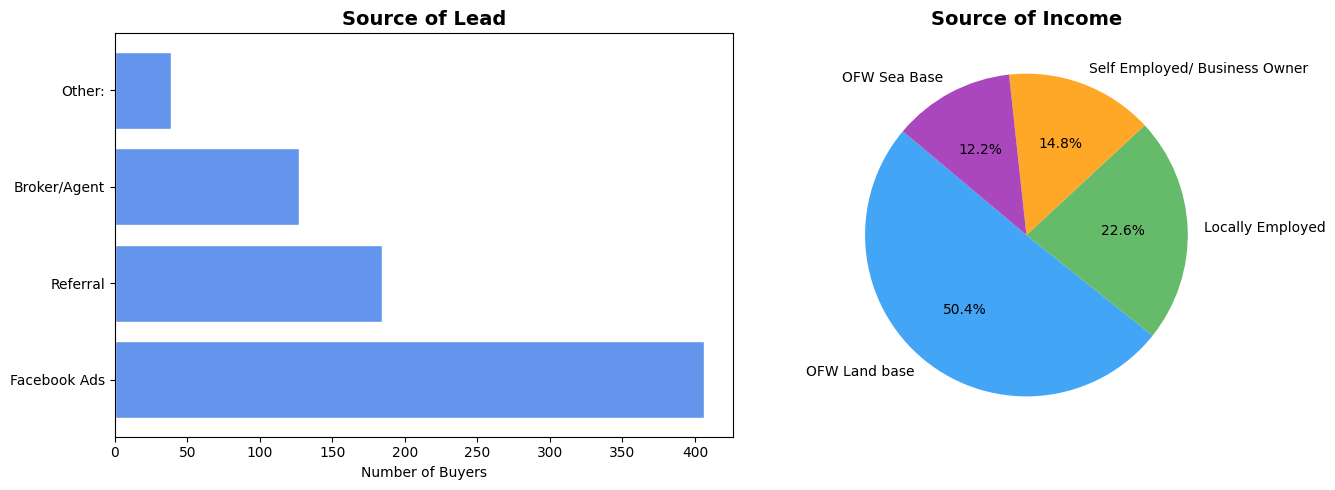

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source of Lead
lead_counts = buyer_lead_df['SOURCE OF LEAD'].value_counts()
axes[0].barh(lead_counts.index, lead_counts.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Source of Lead', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Buyers')

# Source of Income
income_src_counts = buyer_lead_df['Source of Income'].value_counts()
colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']
axes[1].pie(income_src_counts, labels=income_src_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Source of Income', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Feature Correlation and Income Scatter Plot
We analyze the numerical features using a correlation matrix to identify multicollinearity or predictive signals. Additionally, we plot the different types of income against each other, colored by the recommended house model, to visually identify clustering and separation boundaries.

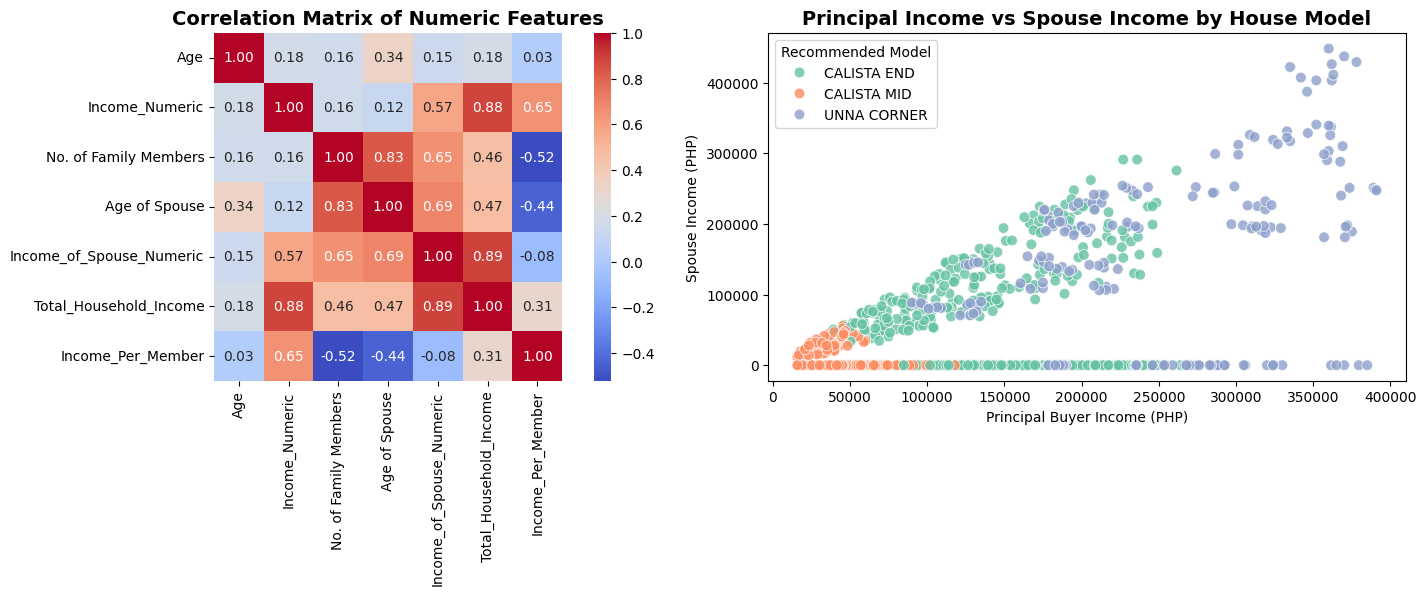

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Matrix Heatmap
numeric_cols = ['Age', 'Income_Numeric', 'No. of Family Members', 'Age of Spouse', 'Income_of_Spouse_Numeric', 'Total_Household_Income', 'Income_Per_Member']
corr = buyer_lead_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0], square=True)
axes[0].set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')

# Scatter Plot for Income Types
# Ensure Recommended Model is clean for consistent coloring
buyer_lead_df['Recommended Model'] = buyer_lead_df['Recommended Model'].str.upper().str.strip()
buyer_lead_df['Recommended Model'] = buyer_lead_df['Recommended Model'].replace('UNNA REGULAR', 'UNNA CORNER')

sns.scatterplot(
    data=buyer_lead_df, 
    x='Income_Numeric', 
    y='Income_of_Spouse_Numeric', 
    hue='Recommended Model', 
    palette='Set2', 
    alpha=0.8, 
    s=60,
    edgecolor='w',
    ax=axes[1]
)
axes[1].set_title('Principal Income vs Spouse Income by House Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Principal Buyer Income (PHP)')
axes[1].set_ylabel('Spouse Income (PHP)')

plt.tight_layout()
plt.show()

## 3. Feature Engineering
We select and transform the most predictive features. We also standardize the target variable casing and merge the rare UNNA REGULAR class (only 6 samples) into UNNA CORNER for better model generalization.

In [9]:
# Select the features based on EDA and user requirements
features = [
    'Age', 
    'Income_Numeric', 
    'Marital Status', 
    'No. of Family Members', 
    'Preferred Pay Term', 
    'Source of Income', 
    'SOURCE OF LEAD', 
    'Age of Spouse', 
    'Income_of_Spouse_Numeric',
    'Has_Spouse',
    'Total_Household_Income',
    'Income_Per_Member',
    'Age_Spouse_Diff'
]
target = 'Recommended Model'

# Create a clean dataframe for modeling
model_df = buyer_lead_df[features + [target]].copy()
model_df = model_df.dropna()

print(f"Data shape for modeling: {model_df.shape}")
print(f"Target class distribution:")
print(model_df[target].value_counts())

# Separate features (X) and target (y)
X = model_df[features]
y = model_df[target]

# One-hot encode categorical features to create dummy variables
categorical_cols = ['Marital Status', 'Preferred Pay Term', 'Source of Income', 'SOURCE OF LEAD']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape of X after One-Hot Encoding: {X_encoded.shape}")
X_encoded.head()

Data shape for modeling: (756, 14)
Target class distribution:
Recommended Model
CALISTA END    378
UNNA CORNER    195
CALISTA MID    183
Name: count, dtype: int64
Shape of X after One-Hot Encoding: (756, 20)


,Age,Income_Numeric,No. of Family Members,Age of Spouse,Income_of_Spouse_Numeric,Has_Spouse,Total_Household_Income,Income_Per_Member,Age_Spouse_Diff,Marital Status_Single,Marital Status_Widow,Preferred Pay Term_20-80 Pagibig Financing,Preferred Pay Term_Cash,Preferred Pay Term_Deferred Cash,Source of Income_OFW Land base,Source of Income_OFW Sea Base,Source of Income_Self Employed/ Business Owner,SOURCE OF LEAD_Facebook Ads,SOURCE OF LEAD_Other:,SOURCE OF LEAD_Referral
0,29,125500,7.0,30.0,83000.0,1,208500.0,29785.714286,1.0,False,False,True,False,False,False,False,False,True,False,False
1,27,61000,2.0,25.0,42500.0,1,103500.0,51750.000000,2.0,False,False,True,False,False,False,False,True,True,False,False
2,42,247000,0.0,0.0,0.0,0,247000.0,247000.000000,42.0,True,False,True,False,False,True,False,False,False,False,False
3,47,32500,0.0,0.0,0.0,0,32500.0,32500.000000,47.0,True,False,True,False,False,True,False,False,True,False,False
4,27,243000,2.0,28.0,224500.0,1,467500.0,233750.000000,1.0,False,False,True,False,False,True,False,False,True,False,False


## 4. Model Training
We split the data using stratified sampling to preserve class proportions, apply feature scaling, and then use GridSearchCV with balanced class weights to handle the class imbalance between housing models.

In [10]:
# Split data using stratified sampling to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training class distribution:")
print(y_train.value_counts())

# Scale features. Logistic Regression performs best with scaled features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use GridSearchCV with StratifiedKFold to find the best hyperparameters
# Using class_weight='balanced' to handle class imbalance
# Scoring with f1_weighted to balance accuracy with minority class detection
param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=10000, solver='saga', penalty='elasticnet', random_state=42),
    param_grid,
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV Score (f1_weighted): {grid.best_score_:.4f}")
log_reg = grid.best_estimator_

print("Model tuning and training complete.")

Training set size: 604
Test set size: 152
Training class distribution:
Recommended Model
CALISTA END    302
UNNA CORNER    156
CALISTA MID    146
Name: count, dtype: int64
Best Parameters: {'C': 0.5, 'class_weight': None, 'l1_ratio': 0.25}
Best CV Score (f1_weighted): 0.9020
Model tuning and training complete.


## 5. Model Evaluation
We evaluate the predictive performance of the trained Logistic Regression model on the unseen test dataset using accuracy, precision, recall, and a confusion matrix.

Accuracy: 0.9013
F1 Score: 0.9019
Classification Report:
              precision    recall  f1-score   support

 CALISTA END       0.89      0.92      0.90        76
 CALISTA MID       1.00      0.86      0.93        37
 UNNA CORNER       0.85      0.90      0.88        39

    accuracy                           0.90       152
   macro avg       0.91      0.89      0.90       152
weighted avg       0.91      0.90      0.90       152



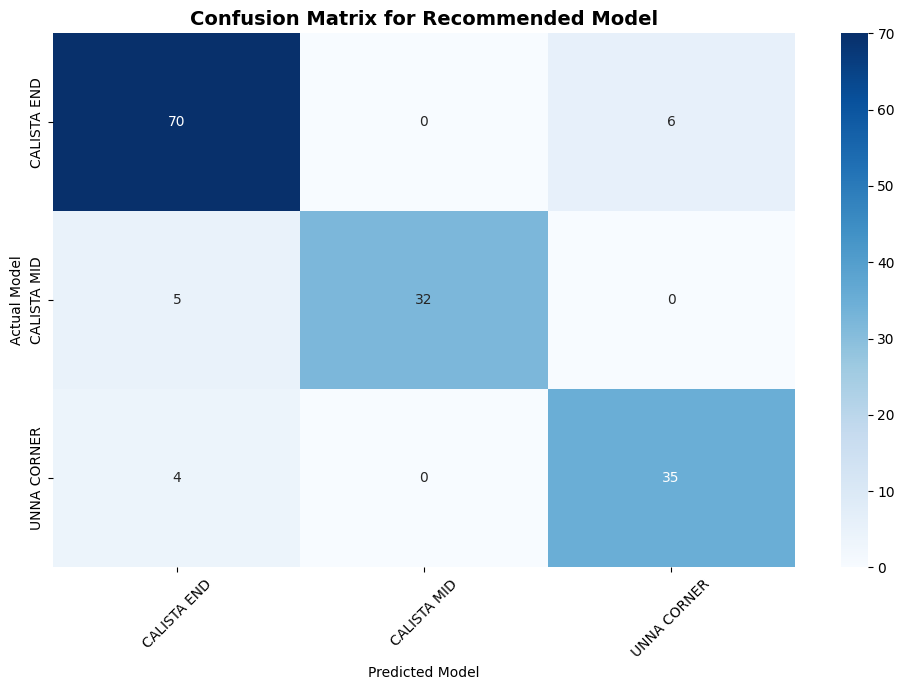

In [11]:
# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Print the full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title('Confusion Matrix for Recommended Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual Model')
plt.xlabel('Predicted Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Model Inference
In this section, we demonstrate how to use the trained Logistic Regression model to make housing model recommendations for prospective buyers. We create a sample input row with the required features, apply the exact same preprocessing (feature engineering, categorical encoding aligned to the training columns, and scaling) before running the prediction.

In [ ]:
# Example of prospective buyer's data
new_client_data = {
    'Age': 32,
    'Income_Numeric': 85000,
    'Marital Status': 'Married',
    'No. of Family Members': 3,
    'Preferred Pay Term': '20-80 Pagibig Financing',
    'Source of Income': 'Locally Employed',
    'SOURCE OF LEAD': 'Facebook Ads',
    'Age of Spouse': 30,
    'Income_of_Spouse_Numeric': 50000
}

# Convert to DataFrame
client_df = pd.DataFrame([new_client_data])

# 1. Feature Engineering
client_df['Has_Spouse'] = client_df['Income_of_Spouse_Numeric'].apply(lambda x: 1 if x > 0 else 0)
client_df['Total_Household_Income'] = client_df['Income_Numeric'] + client_df['Income_of_Spouse_Numeric'].fillna(0)
# Avoid division by zero by setting a minimum of 1 member for per-member calculation
client_df['Income_Per_Member'] = client_df['Total_Household_Income'] / client_df['No. of Family Members'].apply(lambda x: x if x > 0 else 1)
client_df['Age_Spouse_Diff'] = abs(client_df['Age'] - client_df['Age of Spouse'].fillna(0))

# Reorder columns to match the 'features' list used in training
client_df = client_df[features]

# 2. Categorical Encoding
# Perform one-hot encoding on the client data
client_encoded = pd.get_dummies(client_df, columns=categorical_cols, drop_first=True)

# Ensure the client's encoded DataFrame has the exact same columns as the training set (X_encoded)
# Missing columns will be added and filled with False or 0
client_encoded = client_encoded.reindex(columns=X_encoded.columns, fill_value=False)

# 3. Feature Scaling
client_scaled = scaler.transform(client_encoded)

# 4. Prediction
prediction = log_reg.predict(client_scaled)
prediction_prob = log_reg.predict_proba(client_scaled)

print(f"--- Inference Results ---")
print(f"Recommended House Model: {prediction[0]}")

print("\nPrediction Probabilities:")
for model_class, prob in zip(log_reg.classes_, prediction_prob[0]):
    print(f"  {model_class}: {prob * 100:.2f}%")
